In [60]:
import pandas as pd

In [61]:
df=pd.read_excel('Data_Train.xlsx')
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [62]:
df.shape

(10683, 11)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [64]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

##Converting the date and time into a proper int dtype for training model

In [66]:
df['Date']=df['Date_of_Journey'].str.split('/').str[0]
df['month']=df['Date_of_Journey'].str.split('/').str[1]
df['year']=df['Date_of_Journey'].str.split('/').str[2]

In [76]:
df['Date']=df['Date'].astype(int)
df['month']=df['month'].astype(int)
df['year']=df['year'].astype(int)

In [77]:
df.info() ##Now the date,month,year are converted into int

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10683 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
 11  Date             10683 non-null  int32 
 12  month            10683 non-null  int32 
 13  year             10683 non-null  int32 
 14  stops_encoded    10683 non-null  int32 
dtypes: int32(4), int64(1), object(10)
memory usage: 1.1+ MB


In [78]:
##Drop the date of journey
df.drop(columns=['Date_of_Journey'],inplace=True)

In [79]:
df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,month,year,stops_encoded
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,0
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019,2
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019,2
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019,1
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019,1


##Now the arrival and Departure time need to be split

In [80]:
df['Arrival_Time']=df['Arrival_Time'].apply(lambda x:x.split(' ')[0])
df['Arrival_hour']=df['Arrival_Time'].str.split(':').str[0].astype(int)
df['Arrival_minute']=df['Arrival_Time'].str.split(':').str[1].astype(int)
df['Dep_hour']=df['Dep_Time'].str.split(':').str[0].astype(int)
df['Dep_minute']=df['Dep_Time'].str.split(':').str[1].astype(int)

In [81]:
df.drop(columns=['Arrival_Time','Dep_Time'],inplace=True)

In [82]:
df.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,month,year,stops_encoded,Arrival_hour,Arrival_minute,Dep_hour,Dep_minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,0,1,10,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,2,13,15,5,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,2019,2,4,25,9,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,2019,1,23,30,18,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,2019,1,21,35,16,50


##Converted Duration into minutes

In [83]:
df.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,month,year,stops_encoded,Arrival_hour,Arrival_minute,Dep_hour,Dep_minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,0,1,10,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,2,13,15,5,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,2019,2,4,25,9,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,2019,1,23,30,18,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,2019,1,21,35,16,50


In [84]:
df['Duration'] = df['Duration'].str.lower()
df['Duration_min'] = (
    df['Duration']
    .str.extract(r'(?:(\d+)h)?\s*(?:(\d+)m)?')
    .fillna(0)
    .astype(int)
    .apply(lambda x: x[0]*60 + x[1], axis=1)
)

In [85]:
df.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,month,year,stops_encoded,Arrival_hour,Arrival_minute,Dep_hour,Dep_minute,Duration_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,0,1,10,22,20,170
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,2,13,15,5,50,445
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,2019,2,4,25,9,25,1140
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,2019,1,23,30,18,5,325
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,2019,1,21,35,16,50,285


In [86]:
df.drop(columns=['Duration'],inplace=True)

In [87]:
df.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Date,month,year,stops_encoded,Arrival_hour,Arrival_minute,Dep_hour,Dep_minute,Duration_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,2019,0,1,10,22,20,170
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,2019,2,13,15,5,50,445
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,2019,2,4,25,9,25,1140
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,2019,1,23,30,18,5,325
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,2019,1,21,35,16,50,285


In [88]:
df['Total_Stops'].value_counts()

Total_Stops
1 stop      5626
non-stop    3491
2 stops     1520
3 stops       45
4 stops        1
Name: count, dtype: int64

##Handling Missing Values inside the Total_stops

In [89]:
df['Total_Stops']=df['Total_Stops'].fillna(df['Total_Stops'].mode()[0])

In [90]:
df['Total_Stops'].isnull().sum()

0

In [91]:
df['Total_Stops'].value_counts()

Total_Stops
1 stop      5626
non-stop    3491
2 stops     1520
3 stops       45
4 stops        1
Name: count, dtype: int64

In [92]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder(categories=[['non-stop', '1 stop', '2 stops', '3 stops', '4 stops']])
df['stops_encoded'] = oe.fit_transform(df[['Total_Stops']]).astype(int)

Performing Ordinal Encoding to convert the Total_stops(categorical) to labels like 0,1,2,3,4

In [93]:
df.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Date,month,year,stops_encoded,Arrival_hour,Arrival_minute,Dep_hour,Dep_minute,Duration_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,2019,0,1,10,22,20,170
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,2019,2,13,15,5,50,445
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,2019,2,4,25,9,25,1140
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,2019,1,23,30,18,5,325
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,2019,1,21,35,16,50,285


In [100]:
df.drop('Additional_Info',axis=1,inplace=True)

In [101]:
df.head()

,Airline,Source,Destination,Route,Price,Date,month,year,stops_encoded,Arrival_hour,Arrival_minute,Dep_hour,Dep_minute,Duration_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,3897,24,3,2019,0,1,10,22,20,170
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7662,1,5,2019,2,13,15,5,50,445
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,13882,9,6,2019,2,4,25,9,25,1140
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,6218,12,5,2019,1,23,30,18,5,325
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,13302,1,3,2019,1,21,35,16,50,285


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Airline         10683 non-null  object
 1   Source          10683 non-null  object
 2   Destination     10683 non-null  object
 3   Route           10682 non-null  object
 4   Price           10683 non-null  int64 
 5   Date            10683 non-null  int32 
 6   month           10683 non-null  int32 
 7   year            10683 non-null  int32 
 8   stops_encoded   10683 non-null  int32 
 9   Arrival_hour    10683 non-null  int32 
 10  Arrival_minute  10683 non-null  int32 
 11  Dep_hour        10683 non-null  int32 
 12  Dep_minute      10683 non-null  int32 
 13  Duration_min    10683 non-null  int32 
dtypes: int32(9), int64(1), object(4)
memory usage: 793.0+ KB


In [104]:
df.drop('Route', axis=1, inplace=True)

Performing one-hot encoding for the Airlines,source and destination

In [107]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
ohe.fit_transform(df[['Airline','Source','Destination']]).toarray()

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.]])

In [122]:
df1=pd.DataFrame(ohe.fit_transform(df[['Airline','Source','Destination']]).toarray(),columns=ohe.get_feature_names_out())

In [123]:
df_final=pd.concat([df1,df],axis=1)

In [124]:
df_final.drop(columns=['Airline','Source','Destination'],inplace=True)

In [125]:
df_final

,Airline_Air Asia,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,...,Price,Date,month,year,stops_encoded,Arrival_hour,Arrival_minute,Dep_hour,Dep_minute,Duration_min
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3897,24,3,2019,0,1,10,22,20,170
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7662,1,5,2019,2,13,15,5,50,445
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,13882,9,6,2019,2,4,25,9,25,1140
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6218,12,5,2019,1,23,30,18,5,325
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,13302,1,3,2019,1,21,35,16,50,285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4107,9,4,2019,0,22,25,19,55,150
10679,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4145,27,4,2019,0,23,20,20,45,155
10680,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,7229,27,4,2019,0,11,20,8,20,180
10681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,12648,1,3,2019,0,14,10,11,30,160


In [126]:
df_final.columns

Index(['Airline_Air Asia', 'Airline_Air India', 'Airline_GoAir',
       'Airline_IndiGo', 'Airline_Jet Airways', 'Airline_Jet Airways Business',
       'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy',
       'Source_Banglore', 'Source_Chennai', 'Source_Delhi', 'Source_Kolkata',
       'Source_Mumbai', 'Destination_Banglore', 'Destination_Cochin',
       'Destination_Delhi', 'Destination_Hyderabad', 'Destination_Kolkata',
       'Destination_New Delhi', 'Price', 'Date', 'month', 'year',
       'stops_encoded', 'Arrival_hour', 'Arrival_minute', 'Dep_hour',
       'Dep_minute', 'Duration_min'],
      dtype='object')

In [127]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 33 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Airline_Air Asia                           10683 non-null  float64
 1   Airline_Air India                          10683 non-null  float64
 2   Airline_GoAir                              10683 non-null  float64
 3   Airline_IndiGo                             10683 non-null  float64
 4   Airline_Jet Airways                        10683 non-null  float64
 5   Airline_Jet Airways Business               10683 non-null  float64
 6   Airline_Multiple carriers                  10683 non-null  float64
 7   Airline_Multiple carriers Premium economy  10683 non-null  float64
 8   Airline_SpiceJet                           10683 non-null  float64
 9   Airline_Trujet                             10683 non-null  float64
 10  Airline_Vistara       

In [130]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6
)
X=df_final.drop(columns='Price')
y=df_final['Price']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train

,Airline_Air Asia,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,...,Destination_New Delhi,Date,month,year,stops_encoded,Arrival_hour,Arrival_minute,Dep_hour,Dep_minute,Duration_min
8990,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,12,3,2019,2,16,35,6,30,605
3684,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,9,5,2019,1,12,35,11,30,1505
1034,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,24,4,2019,1,22,5,15,45,380
3909,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,21,3,2019,1,1,35,12,50,765
3088,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,24,6,2019,2,19,15,17,15,1560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,27,3,2019,1,4,25,9,0,1165
5191,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,9,5,2019,1,20,45,14,5,400
5390,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,15,5,2019,1,1,30,12,50,760
860,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,3,3,2019,0,3,25,0,40,165


In [131]:
model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [137]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
y_train_pred=model.predict(X_train)
y_test_pred=model.predict(X_test)
print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
print("Test MAE:", mean_absolute_error(y_test, y_test_pred))

print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_test_pred))

Train MAE: 868.5747373559954
Test MAE: 1157.9670864278376
Train R2: 0.9278165102005005
Test R2: 0.8492096662521362


In [ ]:
y_pred = model.predict(X_test)
results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})
results.head(10)

,Actual Price,Predicted Price
0,10844,12385.893555
1,4959,5554.491699
2,14781,13527.161133
3,3858,3921.725342
4,12898,13738.324219
5,10529,10179.266602
6,16079,13790.529297
7,7229,5722.601562
8,3597,3671.453613
9,16289,13883.936523


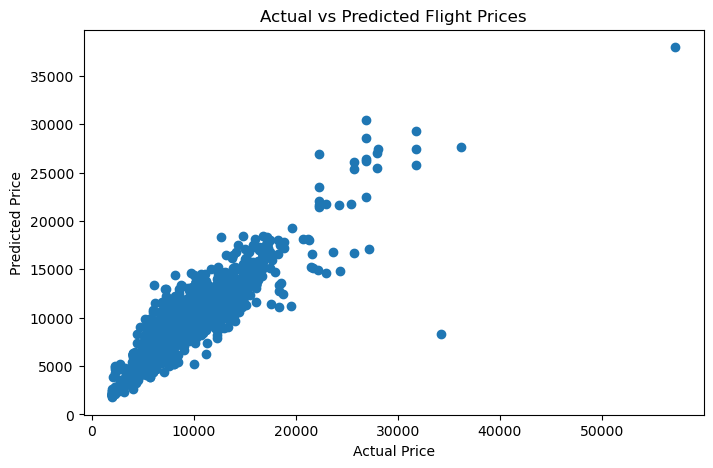

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Flight Prices")
plt.show()

The scatter plot shows a strong positive correlation between actual and predicted flight prices, indicating that the model has successfully learned the underlying pricing pattern.